In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import torchvision.transforms as transforms
import torchvision.models as models
import PIL.Image as Image
from torch.optim import Adam
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset,DataLoader

In [2]:
img_path=[]
labels=[]
for i in os.listdir("/kaggle/input/datasets/omkargurav/face-mask-dataset/data"):
    for label in os.listdir(f"/kaggle/input/datasets/omkargurav/face-mask-dataset/data/{i}"):
        labels.append(i)
        img_path.append(f"/kaggle/input/datasets/omkargurav/face-mask-dataset/data/{i}/{label}")

data_df=pd.DataFrame(zip(img_path,labels),columns=['img_path','labels'])
data_df.head()

,img_path,labels
0,/kaggle/input/datasets/omkargurav/face-mask-da...,without_mask
1,/kaggle/input/datasets/omkargurav/face-mask-da...,without_mask
2,/kaggle/input/datasets/omkargurav/face-mask-da...,without_mask
3,/kaggle/input/datasets/omkargurav/face-mask-da...,without_mask
4,/kaggle/input/datasets/omkargurav/face-mask-da...,without_mask


In [3]:
data_df['img_path'][0]

'/kaggle/input/datasets/omkargurav/face-mask-dataset/data/without_mask/without_mask_3248.jpg'

In [3]:
device='cuda' if torch.cuda.is_available() else "cpu"
print(device)

cuda


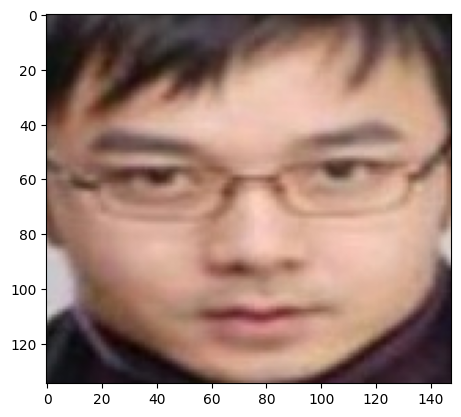

In [5]:
img=Image.open(data_df['img_path'][0])
plt.imshow(img)

In [4]:
train_df=data_df.sample(frac=0.8,random_state=42)
val_df=data_df.drop(train_df.index)
print(train_df.shape)
print(val_df.shape)

(6042, 2)
(1511, 2)


In [5]:
label_encoder=LabelEncoder()
label_encoder.fit(data_df['labels'])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
class MyDataset(Dataset):
    def __init__(self,dataframe,transform):
        self.dataframe=dataframe
        self.transform=transform
        self.label=torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self,idx):
        img_path=self.dataframe.iloc[idx,0]
        label=self.label[idx]
        img=Image.open(img_path).convert('RGB')
        if self.transform:
            img=(self.transform(img)).to(device)
        return img,label

In [7]:
train_dataset=MyDataset(train_df,transform=train_transform)
val_dataset=MyDataset(val_df,transform=val_transform)

In [9]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False)

In [10]:
model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad=False

model.classifier=nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(1280,128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128,2)
)

model=model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s] 

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [11]:
epochs=100
optimizer=Adam(model.classifier.parameters(),lr=0.0001)
criterion=torch.nn.CrossEntropyLoss()

In [12]:
total_train_loss_plot=[]
total_val_loss_plot=[]
total_train_acc_plot=[]
total_val_acc_plot=[]
best_val_loss=float("inf")
counter=0
patience=5


for epoch in range(epochs):
    model.train()
    total_train_loss=0.0
    total_val_loss=0.0
    total_train_acc=0.0
    total_val_acc=0.0
    for img,label in train_loader:
        img,label=img.to(device),label.to(device)
        optimizer.zero_grad()
        pred=model(img)
        loss=criterion(pred,label)
        acc=(torch.argmax(pred,axis=1)==label).sum().item()
        total_train_acc+=acc
        total_train_loss+=loss.item()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.inference_mode():
        for img,label in val_loader:
            img,label=img.to(device),label.to(device)
            pred=model(img)
            acc=(torch.argmax(pred,axis=1)==label).sum().item()
            loss=criterion(pred,label)
            total_val_loss+=loss.item()
            total_val_acc+=acc

    current_val_loss=total_val_loss/len(val_loader)
    current_train_loss=total_train_loss/len(train_loader)
    current_val_acc=(100*total_val_acc/len(val_dataset))
    current_train_acc=(100*total_train_acc/len(train_dataset))
    
    total_train_acc_plot.append(current_train_acc)
    total_train_loss_plot.append(current_train_loss)
    total_val_acc_plot.append(current_val_acc)
    total_val_loss_plot.append(current_val_loss)
    
    print("="*20)
    print(f"Epoch {epoch}/{epochs} Train Acc:{current_train_acc} Train Loss:{current_train_loss}")
    print(f"Epoch {epoch}/{epochs} Val Acc:{current_val_acc} Val Loss:{current_val_loss}")

    if best_val_loss > current_val_loss:
        best_val_loss=current_val_loss
        counter=0
        torch.save({
            'epoch':epoch,
            'acc':current_val_acc,
            'loss':current_val_loss,
            'model_state_dict':model.state_dict()
        },'best_model.pth')
        print("Best Model Saved")

    else:
        counter+=1
        print(f"Counter/Patience: {counter}/{patience} ")

        if counter >= patience:
            print("No Progress, Early Stopping")
            break
    

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 0/100 Train Acc:81.2975835815955 Train Loss:0.5140979668450734
Epoch 0/100 Val Acc:93.64659166115156 Val Loss:0.3017340153455734
Best Model Saved
Epoch 1/100 Train Acc:91.06256206554121 Train Loss:0.27638110266160715
Epoch 1/100 Val Acc:95.89675711449371 Val Loss:0.17362188190842667
Best Model Saved
Epoch 2/100 Train Acc:91.77424693809996 Train Loss:0.21602268067617264
Epoch 2/100 Val Acc:95.96293845135672 Val Loss:0.14387372656104466
Best Model Saved
Epoch 3/100 Train Acc:92.89970208540218 Train Loss:0.19347320847883426
Epoch 3/100 Val Acc:96.75711449371278 Val Loss:0.1218480331202348
Best Model Saved
Epoch 4/100 Train Acc:92.81694803045349 Train Loss:0.18370035663247108
Epoch 4/100 Val Acc:96.62475181998677 Val Loss:0.11406631111943473
Best Model Saved
Epoch 5/100 Train Acc:93.33002317113538 Train Loss:0.1690525973324107
Epoch 5/100 Val Acc:96.36002647253474 Val Loss:0.11607202507245044
Counter/Patience: 1/5 
Epoch 6/100 Train Acc:93.29692154915591 Train Loss:0.1675368421489284

In [33]:
# !pip install mediapipe

In [39]:
# checkpoint=torch.load("best_model.pth",map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.to(device)
# model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [42]:
# this line will download facedetector.tflite file fro google directly
# !wget -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite -O face_detector.tflite

# import cv2
# !pip install mediapipe 
# import mediapipe as mp
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision

base_options=python.BaseOptions(model_asset_path="face_detector.tflite")
options=vision.FaceDetectorOptions(
    base_options=base_options,
    min_detection_confidence=0.5
)
detector=vision.FaceDetector.create_from_options(options)
model.eval()
cap=cv2.VideoCapture(0)
while cap.isOpened():
    ret,frame=cap.read()
    if not ret:
        break

    h,w,_=frame.shape
    rgb_frame=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
    mp_image=mp.Image(image_format=mp.ImageFormat.SRGB,data=rgb_frame)
    detection_results=detector.detect(mp_image)
    if detection_results.detections:
        for detection in detection_results.detections:
            bbox=detection.bounding_box
            xmin=max(0,(bbox.origin_x))
            ymin=max(0,(bbox.origin_y))
            box_w=min(w-xmin,(bbox.width))
            box_h=min(h-ymin,(bbox.height))

            if box_w>0 and box_h>0:
                face_crop=rgb_frame[ymin:ymin+box_h,xmin:xmin+box_w]
                pil_img=Image.fromarray(face_crop)
                input_tensor=val_transform(pil_img).unsqueeze(0).to(device)

                with torch.inference_mode():
                    output=model(input_tensor)
                    pred=torch.argmax(output,axis=1).item()
                label=label_encoder.inverse_transform([pred])[0]

                color=(0,255,0) if label=='with_mask' else (255,0,0)
                cv2.rectangle(frame,(xmin,ymin),(xmin+box_w,ymin+box_h),color,2)
                cv2.putText(frame,str(label),(xmin,ymin-10),cv2.FONT_HERSHEY_COMPLEX,0.8,2)
    cv2.imshow("Mobilenetv2+Mediapipe facemask detection",frame)
    if cv2.waitKey(1) & 0xFF==ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

W0000 00:00:1784767174.450104    3997 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
[ WARN:0@3896.866] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index


error: OpenCV(4.13.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [13]:
import joblib
joblib.dump(label_encoder,"label_encoder.pkl")

['label_encoder.pkl']